### Simulacion de Procesos Financieros
Andre Esteban Vera - 745232
19/08/2026

## Clase 2 - Numeros Pseudoaleatorios



In [3]:
# Generar 10 numeros aleatorios que cumplan con las siguientes condiciones

m = 9
a = 5
b = 1
x0 = 21

def generar_numeros_aleatorios(m, a, b, x0, n): 
    numeros_aleatorios = []
    x = x0
    for i in range(n):
        x = (a * x + b) % m
        numeros_aleatorios.append(x)
    return numeros_aleatorios

numeros = generar_numeros_aleatorios(m, a, b, x0, 10)
print(numeros)

[7, 0, 1, 6, 4, 3, 7, 0, 1, 6]


In [4]:
# Generar 50 numeros aleatorios que cumplan con las siguientes condiciones

m = 16
a = 5
b = 3
x0 = 7

def generar_numeros_aleatorios(m, a, b, x0, n): 
    numeros_aleatorios = []
    x = x0
    for i in range(n):
        x = (a * x + b) % m
        numeros_aleatorios.append(x)
    return numeros_aleatorios

numeros = generar_numeros_aleatorios(m, a, b, x0, 50)
print(numeros)

[6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7, 6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7, 6, 1, 8, 11, 10, 5, 12, 15, 14, 9, 0, 3, 2, 13, 4, 7, 6, 1]


In [6]:
# Generar 10^4 numeros aleatorios que cumplan con las siguientes condiciones

m = (2**31) - 1
a = 1103515245
b = 12345
x0 = 745232

def generar_numeros_aleatorios(m, a, b, x0, n): 
    numeros_aleatorios = []
    x = x0
    for i in range(n):
        x = (a * x + b) % m
        numeros_aleatorios.append(x)
    return numeros_aleatorios

numeros = generar_numeros_aleatorios(m, a, b, x0, 10**4)

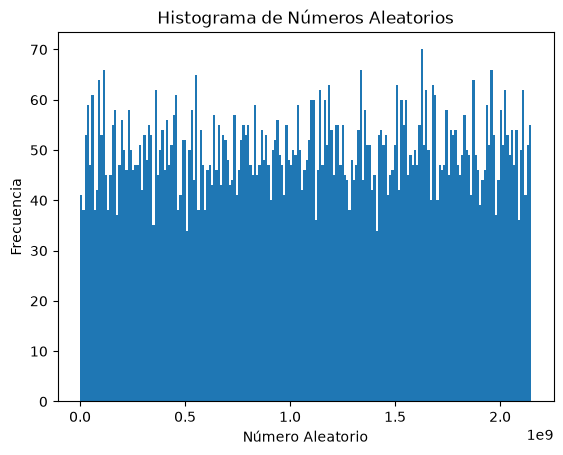

In [10]:
# hacer un histograma de los numeros generados
import matplotlib.pyplot as plt

plt.hist(numeros, bins=200)
plt.xlabel('Número Aleatorio')
plt.ylabel('Frecuencia')
plt.title('Histograma de Números Aleatorios')
plt.show()


In [11]:
(2**31)-1

2147483647

In [12]:
# adaptar el generador anterior para que genere numeros aleatorios entre 2 y 5, incluyendo flotantes, la misma cantidad de numeros aleatorios, 10^4, y que se guarden en un arreglo.
m = (2**31) - 1
a = 1103515245
b = 12345
x0 = 745232

def generar_numeros_aleatorios_intervalo(m, a, b, x0, n):
    numeros_aleatorios = []
    x = x0
    for i in range(n):
        x = (a * x + b) % m
        # Normalizamos a entre 0 y 1
        x_normalizado = x / (m - 1) # pq m-1 es el maximo valor que puede tomar x, entonces al dividirlo entre m-1 obtenemos un valor entre 0 y 1
        # Escalar el valor al rango deseado [min_val, max_val]
        x_escalado = 2 + (5 - 2) * x_normalizado
        numeros_aleatorios.append(x_escalado)
    return numeros_aleatorios

numeros_intervalo = generar_numeros_aleatorios_intervalo(m, a, b, x0, 10**4)




In [15]:
# METODO BOX-MULLER
# generar dos distribucuiones uniformes (u1 y u2, con valores entre 0 y 0.9) con el generador siguiente:

m = 16
a = 5
b = 3
x0_1 = 0
x0_2 = 3
n = 30

def generar_numeros_aleatorios(m, a, b, x0, n): 
    numeros_aleatorios = []
    x = x0
    for i in range(n):
        x = (a * x + b) % m
        # Normalizamos a entre 0 y 0.9
        x_normalizado = 0.9 * x / (m - 1) # pq m-1 es el maximo valor que puede tomar x, entonces al dividirlo entre m-1 obtenemos un valor entre 0 y 1
        numeros_aleatorios.append(x_normalizado)
    return numeros_aleatorios

u1 = generar_numeros_aleatorios(m, a, b, x0_1, n)
u2 = generar_numeros_aleatorios(m, a, b, x0_2, n)

print(u1)
print(u2)


[0.18000000000000002, 0.12000000000000001, 0.78, 0.24000000000000002, 0.42, 0.36000000000000004, 0.060000000000000005, 0.48000000000000004, 0.66, 0.6, 0.3, 0.7200000000000001, 0.9, 0.84, 0.5399999999999999, 0.0, 0.18000000000000002, 0.12000000000000001, 0.78, 0.24000000000000002, 0.42, 0.36000000000000004, 0.060000000000000005, 0.48000000000000004, 0.66, 0.6, 0.3, 0.7200000000000001, 0.9, 0.84]
[0.12000000000000001, 0.78, 0.24000000000000002, 0.42, 0.36000000000000004, 0.060000000000000005, 0.48000000000000004, 0.66, 0.6, 0.3, 0.7200000000000001, 0.9, 0.84, 0.5399999999999999, 0.0, 0.18000000000000002, 0.12000000000000001, 0.78, 0.24000000000000002, 0.42, 0.36000000000000004, 0.060000000000000005, 0.48000000000000004, 0.66, 0.6, 0.3, 0.7200000000000001, 0.9, 0.84, 0.5399999999999999]


In [17]:
# Ahora aplicamos el Metodo de Box - Muller para generar una distribucion normal a partir de estas dos distribuciones uniformes.
import numpy as np

R = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x1 = R * np.cos(theta)
x2 = R * np.sin(theta)
print(x1)
print(x2)



C:\Users\chino\AppData\Local\Temp\ipykernel_18548\3249651894.py:4: RuntimeWarning: divide by zero encountered in log
  R = np.sqrt(-2 * np.log(u1))


TypeError: can't multiply sequence by non-int of type 'float'